In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import dendropy
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
import pickle
from matplotlib.colors import ListedColormap, PowerNorm, LinearSegmentedColormap
import os
from scipy.stats import spearmanr





In [2]:
# Load evolutionary distance matrix
evo_distances = np.load("../data/evo_distance_matrix.npy")

# Load the pickle file
with open('../repos/generalization_transformer/results/supplementary/training_dynamics_raw.pkl', 'rb') as f:
    train_dyn = pickle.load(f)

with open('../repos/generalization_transformer/results/supplementary/evolutionary_similarity.pkl', 'rb') as f:
    evol_dist_sim = pickle.load(f)


In [5]:
evo_distances

array([[  0.     , 181.67932, 143.88848, ..., 139.78556, 150.20098,
        150.20098],
       [181.67932,   0.     , 181.67932, ..., 181.67932, 181.67932,
        181.67932],
       [143.88848, 181.67932,   0.     , ..., 143.88848, 150.20098,
        150.20098],
       ...,
       [139.78556, 181.67932, 143.88848, ...,   0.     , 150.20098,
        150.20098],
       [150.20098, 181.67932, 150.20098, ..., 150.20098,   0.     ,
        140.83644],
       [150.20098, 181.67932, 150.20098, ..., 150.20098, 140.83644,
          0.     ]], shape=(71, 71))

In [12]:
# Explore evol_dist_sim
print("\nType of evol_dist_sim:", type(evol_dist_sim))
if isinstance(evol_dist_sim, dict):
    print("Keys:", evol_dist_sim.keys())
    if len(evol_dist_sim) > 0:
        first_key = list(evol_dist_sim.keys())[0]
        print(f"Type of evol_dist_sim[{first_key}]:", type(evol_dist_sim[first_key]))
elif isinstance(evol_dist_sim, np.ndarray):
    print("Shape of evol_dist_sim:", evol_dist_sim.shape)

Type of alpha_rep_sim: <class 'dict'>
Keys: dict_keys([0.0, 0.25, 0.5, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0])
Type of alpha_rep_sim[0.0]: <class 'numpy.ndarray'>
Shape of alpha_rep_sim[0.0]: (71, 71)

Type of evol_dist_sim: <class 'numpy.ndarray'>
Shape of evol_dist_sim: (71, 71)


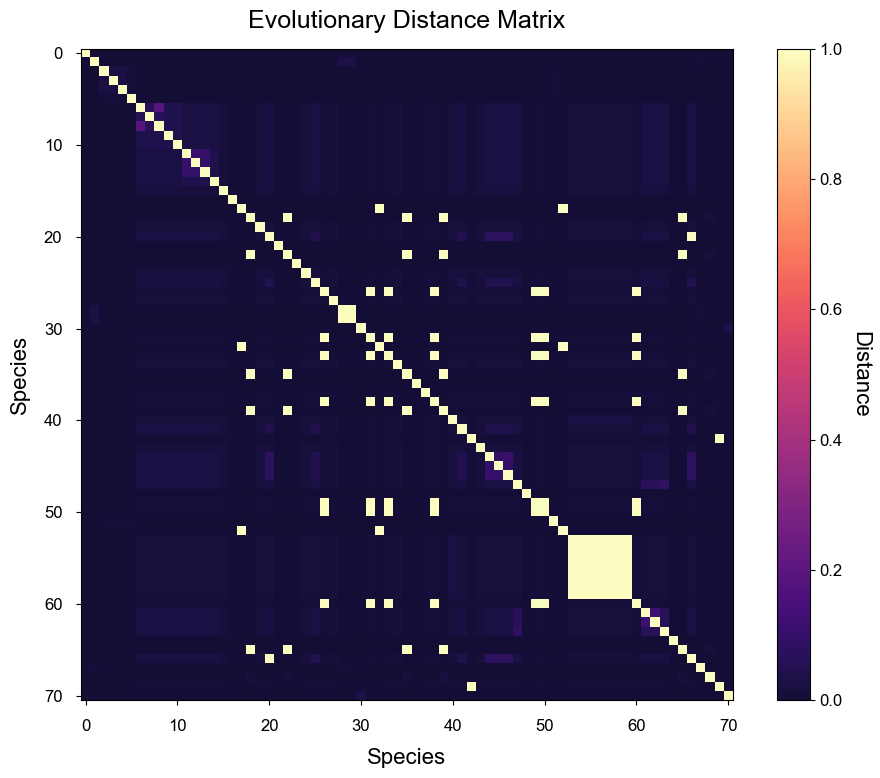

In [32]:
# Set consistent font parameters
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Helvetica']
})

# Create a truncated magma colormap (using 0 to 0.9 range for better visualization)
truncated_magma = ListedColormap(plt.cm.magma(np.linspace(0.1, 1.0, 256)))

# Create a single figure for the evolutionary distance matrix
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the evolutionary distance matrix
im = ax.imshow(evol_dist_sim, cmap=truncated_magma)

# Add a colorbar with improved styling
cbar = plt.colorbar(im, ax=ax, label='Distance')
cbar.ax.set_ylabel('Distance', fontsize=16, rotation=270, labelpad=20)
cbar.ax.tick_params(labelsize=12)

# Set title and labels with consistent styling
ax.set_title('Evolutionary Distance Matrix', fontsize=18, pad=15)
ax.set_xlabel('Species', fontsize=16, labelpad=10)
ax.set_ylabel('Species', fontsize=16, labelpad=10)

# Add tick parameters for better readability
ax.tick_params(axis='both', which='major', labelsize=12, pad=10)

# Improve the plot's visual appearance
ax.set_facecolor('white')
ax.grid(False)  # Remove grid for cleaner look with a matrix

# Ensure axes are tight and there's no extra whitespace
plt.tight_layout()

# Optional: uncomment to save the figure
# plt.savefig('evolutionary_distance_matrix.pdf', bbox_inches='tight', dpi=300)

plt.show()

Successfully loaded similarity matrix with shape: (71, 71)
Value range: Min=0.0000, Max=1.0000, Mean=0.0427
1th percentile: 0.0000
5th percentile: 0.0000
10th percentile: 0.0000
25th percentile: 0.0010
50th percentile: 0.0011
75th percentile: 0.0134
90th percentile: 0.0188
95th percentile: 0.0318
99th percentile: 1.0000


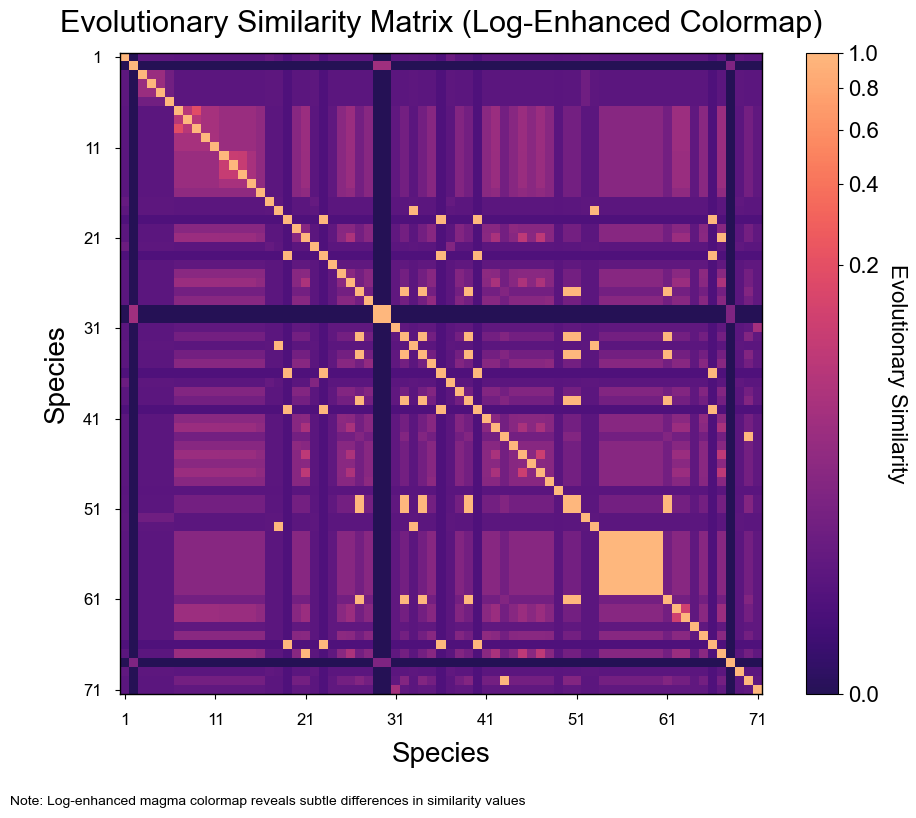

In [95]:
# File path for the evolutionary similarity matrix
file_path = '../repos/generalization_transformer/results/supplementary/evolutionary_similarity_matrix.npy'

# Load the evolutionary similarity matrix
try:
    similarity_matrix = np.load(file_path)
    print(f"Successfully loaded similarity matrix with shape: {similarity_matrix.shape}")
    print(f"Value range: Min={np.min(similarity_matrix):.4f}, Max={np.max(similarity_matrix):.4f}, Mean={np.mean(similarity_matrix):.4f}")
    
    # Calculate percentiles to understand the distribution
    percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
    for p in percentiles:
        value = np.percentile(similarity_matrix, p)
        print(f"{p}th percentile: {value:.4f}")
except Exception as e:
    print(f"Error loading similarity matrix: {e}")
    similarity_matrix = np.random.rand(20, 20)
    print("Using dummy data for demonstration purposes.")

# Set consistent font parameters
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Helvetica']
})

# Now create a single optimized version with magma colormap and non-linear scaling
plt.figure(figsize=(10, 8))
ax = plt.gca()

# Using a focused range of the magma colormap
optimized_magma = ListedColormap(plt.cm.magma(np.linspace(0.15, 0.85, 256)))

# Apply a logarithmic transformation to better separate the lower values
log_norm = PowerNorm(gamma=0.25)  # Even stronger gamma correction to enhance differences

# Plot with the optimized settings
im = ax.imshow(similarity_matrix, cmap=optimized_magma, norm=log_norm, aspect='equal')

# Add colorbar
cbar = plt.colorbar(im)
cbar.ax.set_ylabel('Evolutionary Similarity', fontsize=16, rotation=270, labelpad=20)
cbar.ax.tick_params(labelsize=16)

# Set title and labels
plt.title("Evolutionary Similarity Matrix (Log-Enhanced Colormap)", fontsize=22, pad=15)
plt.xlabel('Species', fontsize=20, labelpad=10)
plt.ylabel('Species', fontsize=20, labelpad=10)

# Add tick parameters
plt.tick_params(axis='both', which='major', labelsize=12, pad=10)

# If the matrix is large, limit the number of ticks
matrix_size = similarity_matrix.shape[0]
if matrix_size > 20:
    tick_spacing = max(1, matrix_size // 7)
    tick_positions = np.arange(0, matrix_size, tick_spacing)
    plt.xticks(tick_positions, [str(i+1) for i in tick_positions])
    plt.yticks(tick_positions, [str(i+1) for i in tick_positions])

# Add borders
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1)

# Add a note explaining the color scale
plt.figtext(0.05, -0.02, 
            "Note: Log-enhanced magma colormap reveals subtle differences in similarity values", 
            fontsize=10, ha='left')

plt.tight_layout()

# # Save the optimized figure
plt.savefig(os.path.join(output_dir, 'evolutionary_similarity_magma_log_enhanced.pdf'), 
           bbox_inches='tight', dpi=300)
# plt.savefig(os.path.join(output_dir, 'evolutionary_similarity_magma_log_enhanced.png'), 
#            bbox_inches='tight', dpi=300)

plt.show()

Loaded matrix for alpha=0.0, shape=(200, 200)
Loaded matrix for alpha=0.5, shape=(200, 200)
Loaded matrix for alpha=0.75, shape=(200, 200)
Loaded matrix for alpha=0.85, shape=(200, 200)
Loaded matrix for alpha=1.0, shape=(200, 200)
Common color range: vmin=0.013359451666474342, vmax=0.9999995231628418


/tmp/ipykernel_3532441/272065626.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 0.95])


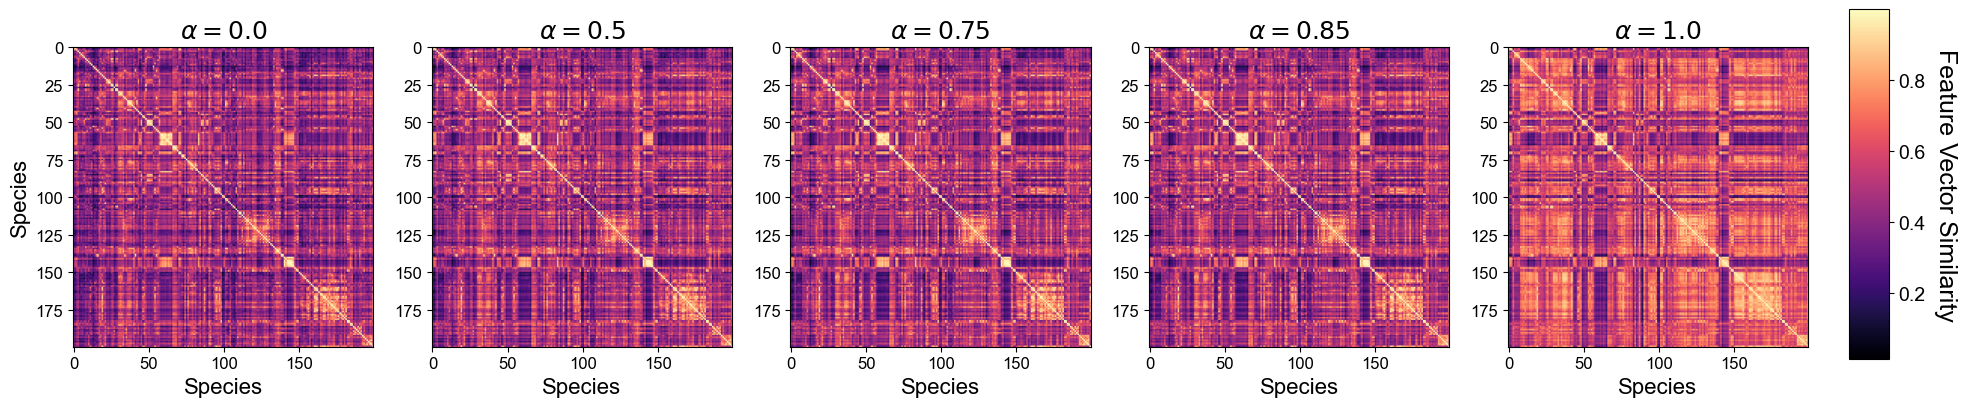

In [49]:
# Base path for the similarity matrices
base_path = '../repos/generalization_transformer/results/supplementary/'

# Selected alpha values to display
selected_alphas = [0.0, 0.5, 0.75, 0.85, 1.0]

# Function to load similarity matrices for each alpha
def load_similarity_matrices(base_path, selected_alphas):
    alpha_rep_sim = {}
    
    for alpha in selected_alphas:
        # Construct the file path for each alpha value
        file_path = os.path.join(base_path, f'similarity_matrix_alpha{alpha:.1f}.npy')
        
        # Try to load the file if it exists
        if os.path.exists(file_path):
            try:
                matrix = np.load(file_path)
                alpha_rep_sim[alpha] = matrix
                print(f"Loaded matrix for alpha={alpha}, shape={matrix.shape}")
            except Exception as e:
                print(f"Error loading matrix for alpha={alpha}: {e}")
        else:
            print(f"File not found for alpha={alpha}: {file_path}")
            
            # Try alternative formatting (some files might use different decimal notation)
            alt_file_path = os.path.join(base_path, f'similarity_matrix_alpha{alpha}.npy')
            if os.path.exists(alt_file_path):
                try:
                    matrix = np.load(alt_file_path)
                    alpha_rep_sim[alpha] = matrix
                    print(f"Loaded matrix for alpha={alpha} (alternative format), shape={matrix.shape}")
                except Exception as e:
                    print(f"Error loading matrix for alpha={alpha} (alternative format): {e}")
    
    return alpha_rep_sim

# Load the similarity matrices
alpha_rep_sim = load_similarity_matrices(base_path, selected_alphas)

# Set consistent font parameters
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Helvetica']
})

# Create a truncated magma colormap (from 0.1 to 1.0 for better contrast)
truncated_magma = ListedColormap(plt.cm.magma(np.linspace(0, 1.0, 256)))

# Create the figure and subplots with proper sizing
fig, axs = plt.subplots(1, len(selected_alphas), figsize=(20, 5))
#fig.suptitle('Alpha Representation Similarity Matrices', fontsize=20, y=0.98)

# Create a common normalization to ensure consistent coloring across all matrices
all_matrices = [alpha_rep_sim[alpha] for alpha in selected_alphas if alpha in alpha_rep_sim]
if all_matrices:
    vmin = min(np.min(matrix) for matrix in all_matrices)
    vmax = max(np.max(matrix) for matrix in all_matrices)
    print(f"Common color range: vmin={vmin}, vmax={vmax}")
else:
    vmin, vmax = 0, 1  # Default if no matrices are available
    print("No matrices found, using default color range")

# Track the last valid image for the colorbar
last_im = None

# Plot each matrix
for i, alpha in enumerate(selected_alphas):
    # Set the background color for each subplot
    axs[i].set_facecolor('white')
    
    if alpha in alpha_rep_sim:
        # Plot the matrix with consistent color scaling
        im = axs[i].imshow(alpha_rep_sim[alpha], cmap=truncated_magma, vmin=vmin, vmax=vmax)
        last_im = im  # Store for colorbar
        
        # Add title and labels with LaTeX formatting for alpha
        axs[i].set_title(f'$\\alpha = {alpha}$', fontsize=18)
        axs[i].set_xlabel('Species', fontsize=16)
        
        # Only add y-label for the first subplot
        if i == 0:
            axs[i].set_ylabel('Species', fontsize=16)
            
        # Customize tick parameters for better readability
        axs[i].tick_params(axis='both', which='major', labelsize=12)
        
        # Add a grid for better readability of the matrix
        axs[i].grid(False)
    else:
        # Display a message if data is not available
        axs[i].text(0.5, 0.5, f"$\\alpha = {alpha}$\n(not available)", 
                   ha='center', va='center', fontsize=16,
                   transform=axs[i].transAxes)
        
        # Remove ticks and spines for empty subplots
        axs[i].set_xticks([])
        axs[i].set_yticks([])
        for spine in axs[i].spines.values():
            spine.set_visible(False)

# Add a common colorbar if we have at least one valid plot
if last_im is not None:
    # Adjust subplot spacing to make room for colorbar
    fig.subplots_adjust(right=0.92)
    
    # Create colorbar axis
    cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
    
    # Add colorbar with improved styling
    cbar = fig.colorbar(last_im, cax=cbar_ax)
    cbar.ax.set_ylabel('Feature Vector Similarity', fontsize=18, rotation=270, labelpad=22)
    cbar.ax.tick_params(labelsize=14)

# Improve overall layout
plt.tight_layout(rect=[0, 0, 0.92, 0.95])

# Save the figure with high resolution
plt.savefig(os.path.join(base_path, 'alpha_similarity_matrices.pdf'), 
           bbox_inches='tight', dpi=300)
# plt.savefig(os.path.join(base_path, 'alpha_similarity_matrices.png'), 
#            bbox_inches='tight', dpi=300)
plt.show()